In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# 1. LOAD DATA
df = pd.read_csv("sales_data.csv")

In [3]:
# 2. PREPROCESSING
le = LabelEncoder()
cols_to_encode = ['product_category_name', 'seller_state', 'seller_city']
for col in cols_to_encode:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

df['price_segment'] = pd.qcut(df['avg_order_value'], q=3, labels=[0, 1, 2]).astype(int)
threshold = df['total_sales'].median()
df['performance_tier'] = (df['total_sales'] > threshold).astype(int)

features_final = ['total_orders', 'price_segment', 'product_category_name', 'seller_state', 'seller_city']
X = df[features_final]
y = df['performance_tier']

# PENTING: SVM WAJIB pakai Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [4]:
# 3. TRAINING
# dual=False disarankan jika jumlah data > jumlah fitur
model = LinearSVC(random_state=42, dual=False)
model.fit(X_train, y_train)

LinearSVC(dual=False, random_state=42)

In [5]:
# 4. EVALUASI
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 40)
print("=== FINAL RESULT: SUPPORT VECTOR MACHINE (SVM) ===")
print(f"Akurasi Model pada Data Ujian: {accuracy * 100:.2f}%")
print("-" * 40)
print(classification_report(y_test, y_pred))

# SVM Linear juga punya koefisien
print("-" * 40)
print("Faktor Penentu (Koefisien SVM):")
coeffs = pd.Series(model.coef_[0], index=features_final)
print(coeffs.sort_values(ascending=False))

----------------------------------------
=== FINAL RESULT: SUPPORT VECTOR MACHINE (SVM) ===
Akurasi Model pada Data Ujian: 92.57%
----------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      4589
           1       0.90      0.96      0.93      4558

    accuracy                           0.93      9147
   macro avg       0.93      0.93      0.93      9147
weighted avg       0.93      0.93      0.93      9147

----------------------------------------
Faktor Penentu (Koefisien SVM):
total_orders             3.529019
price_segment            1.080516
seller_state             0.004971
product_category_name    0.004427
seller_city             -0.018734
dtype: float64


----------------------------------------
ROC-AUC Score: 0.9586
----------------------------------------
Confusion Matrix:
[[4105  484]
 [ 196 4362]]


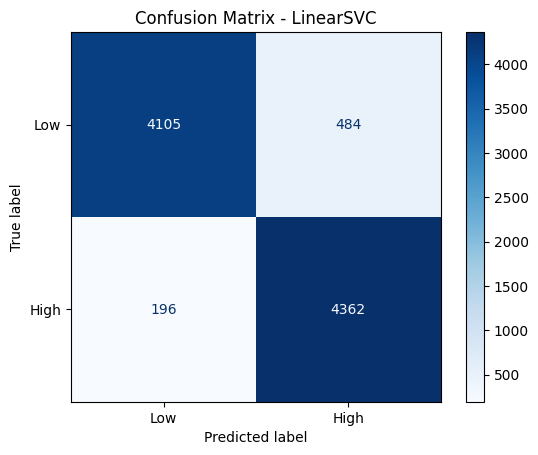

In [6]:
# Hitung Confusion Matrix, btw gw copy paste ini smw ke 5 modelny, mager
cm = confusion_matrix(y_test, y_pred)

# Hitung ROC-AUC
# Cek apakah model punya method predict_proba (DT, RF, GBT, LR punya)
# SVM LinearSVC g punya predict_proba default, jadi pakai decision_function atau y_pred biasa
try:
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_score = roc_auc_score(y_test, y_prob)
except AttributeError:
    # Fallback untuk SVM LinearSVC atau jika error
    try:
        y_prob = model.decision_function(X_test)
        roc_score = roc_auc_score(y_test, y_prob)
    except:
        roc_score = roc_auc_score(y_test, y_pred)

print("-" * 40)
print(f"ROC-AUC Score: {roc_score:.4f}")
print("-" * 40)
print("Confusion Matrix:")
print(cm)

# 3. Tampilkan Plot Confusion Matrix
# 0 = Low Performance, 1 = High Performance
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {model.__class__.__name__}")
plt.show()

# Kotak Kiri Atas & Kanan Bawah (Biru Gelap): Jawaban Benar. Makin gelap makin bagus.
# Kotak Kanan Atas (False Positive): Model bilang "Sukses", aslinya "Gagal".
# Kotak Kiri Bawah (False Negative): Model bilang "Gagal", aslinya "Sukses".